
# Uncovering Disease Comorbidity Patterns and Readmission Mechanisms in Diabetic Patients Using Association Rule Mining



In [1]:

# ============================================
# IMPORTS & BASIC SETUP
# ============================================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import re
import time

sns.set(style="whitegrid")

from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import fpgrowth


In [2]:

#!pip install mlxtend



## 1. Load Data


In [17]:

# ============================================
# 1. LOAD RAW DATA
# ============================================

csv_path = r"C:\Users\Arun Krishna\Desktop\Submission\diabetic_data.csv"

df_raw = pd.read_csv(csv_path)
print("Raw shape:", df_raw.shape)
df_raw.head()


Raw shape: (101766, 50)


,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO



## 2. Select Relevant Columns & Clean Data

We keep:
- gender, age  
- diag\_1, diag\_2, diag\_3  
- insulin, change  
- readmitted  


In [3]:

# ============================================
# 2. SELECT RELEVANT COLUMNS & BASIC CLEANING
# ============================================

df = df_raw[['gender', 'age', 'diag_1', 'diag_2', 'diag_3',
             'insulin', 'change', 'readmitted']].copy()

# Replace '?' with 'Unknown' and fill any NaN with 'Unknown'
df.replace('?', 'Unknown', inplace=True)
df.fillna('Unknown', inplace=True)

# Tidy up string formatting
df['gender'] = df['gender'].str.strip().str.capitalize()
df['insulin'] = df['insulin'].str.strip().str.capitalize()

# Recode change: Ch -> Changed, No -> NoChange
df['change'] = df['change'].replace({
    'Ch': 'Changed',
    'No': 'NoChange'
})

# Clean age brackets: [20-30) -> 20-30, <30 -> 0-30, etc.
df['age'] = df['age'].str.replace(r'[\[\)\<\>]', '', regex=True)

# Recode readmission into 2 classes
df['readmitted'] = df['readmitted'].replace({
    '<30': 'Readmitted',
    '>30': 'Not_Readmitted',
    'NO': 'Not_Readmitted'
})

print("Cleaned shape:", df.shape)
df.head()


Cleaned shape: (101766, 8)


,gender,age,diag_1,diag_2,diag_3,insulin,change,readmitted
0,Female,0-10,250.83,Unknown,Unknown,No,NoChange,Not_Readmitted
1,Female,10-20,276,250.01,255,Up,Changed,Not_Readmitted
2,Female,20-30,648,250,V27,No,NoChange,Not_Readmitted
3,Male,30-40,8,250.43,403,Up,Changed,Not_Readmitted
4,Male,40-50,197,157,250,Steady,Changed,Not_Readmitted


In [6]:
def map_icd9_to_panel_39(code):
    if pd.isna(code):
        return "Unknown"
    s = str(code).strip().upper()
    if s == "" or s in {"?", "UNKNOWN", "NAN"}:
        return "Unknown"

    if s.startswith("V"):
        return "Factors Influencing Health Status and Contact with Health Services (V Codes)"
    if s.startswith("E"):
        return "External Causes (E Codes)"
    if s.startswith("M"):
        return "Morphology of Neoplasms (M Codes)"

    num = re.sub(r"[^0-9.]", "", s)
    if num == "":
        return "Other and unspecified mortality and morbidity"
    try:
        ival = int(float(num))
    except:
        return "Other and unspecified mortality and morbidity"

    if 1 <= ival <= 139:
        return "Infectious disorders"
    if 140 <= ival <= 239:
        return "Neoplasms"
    if 240 <= ival <= 279:
        if 270 <= ival <= 275 or ival == 277 or ival == 279:
            return "Inherited metabolic, and immune disorders"
        if ival == 276:
            return "Fluid and electrolyte disorders"
        if ival == 278:
            return "Nutritional disorders"
        return "Endocrine disorders"
    if 280 <= ival <= 289:
        return "Hematologic disorders"
    if 290 <= ival <= 319:
        if 291 <= ival <= 292 or 303 <= ival <= 305:
            return "Substance abuse"
        return "Psychiatric disorders"
    if 320 <= ival <= 389:
        if 360 <= ival <= 379:
            return "ENT and eye disorders"
        return "Neurological disorders"
    if 390 <= ival <= 459:
        if 454 <= ival <= 457:
            return "Varicose veins, haemorrhoids, and lymphatic disorders"
        return "Cardiovascular disorders"
    if 460 <= ival <= 519:
        return "Respiratory disorders"
    if 520 <= ival <= 525:
        return "Dental disorders"
    if 520 <= ival <= 579:
        return "Digestive system disorders"
    if 580 <= ival <= 629:
        return "Genitourinary disorders"
    if 630 <= ival <= 639:
        return "Gynecological disorders"
    if 640 <= ival <= 679:
        return "Pregnancy, childbirth, and puerperium"
    if 610 <= ival <= 611:
        return "Breast disorders"
    if 628 <= ival <= 628:
        return "Infertility disorders"
    if 680 <= ival <= 709:
        return "Skin and subcutaneous disorders"
    if 710 <= ival <= 739:
        return "Musculoskeletal and connective tissue disorders"
    if 740 <= ival <= 759:
        return "Congenital anomalies"
    if 760 <= ival <= 779:
        return "Perinatal conditions"
    if 780 <= ival <= 799:
        return "Nonspecific abnormal findings"
    if 800 <= ival <= 909:
        return "Injuries"
    if 910 <= ival <= 924:
        return "Effects of foreign body entering through orifice"
    if 925 <= ival <= 929:
        return "Certain adverse effects not elsewhere classified"
    if 930 <= ival <= 939:
        return "Toxic effects of substances"
    if 940 <= ival <= 949:
        return "Complications from a Procedure or Device"
    if 950 <= ival <= 957:
        return "Complications of Medical Care"
    if 958 <= ival <= 959:
        return "Late Effects"
    if 960 <= ival <= 979:
        return "Poisonings by drugs, medicaments, and biological substances"
    if 980 <= ival <= 999:
        return "Other and unspecified mortality and morbidity"

    return "Unknown"


for col in ['diag_1', 'diag_2', 'diag_3']:
    if col in df.columns:
        df[col + '_cat39'] = df[col].apply(map_icd9_to_panel_39)

if all(col in df.columns for col in ['diag_1','diag_2','diag_3']):
    df.drop(columns=['diag_1','diag_2','diag_3'], inplace=True)


df.head()

,gender,age,insulin,change,readmitted,diag_1_cat39,diag_2_cat39,diag_3_cat39
0,Female,0-10,No,NoChange,Not_Readmitted,Endocrine disorders,Unknown,Unknown
1,Female,10-20,Up,Changed,Not_Readmitted,Fluid and electrolyte disorders,Endocrine disorders,Endocrine disorders
2,Female,20-30,No,NoChange,Not_Readmitted,"Pregnancy, childbirth, and puerperium",Endocrine disorders,Factors Influencing Health Status and Contact ...
3,Male,30-40,Up,Changed,Not_Readmitted,Infectious disorders,Endocrine disorders,Cardiovascular disorders
4,Male,40-50,Steady,Changed,Not_Readmitted,Neoplasms,Neoplasms,Endocrine disorders



## 3. Quick Exploratory Data Analysis


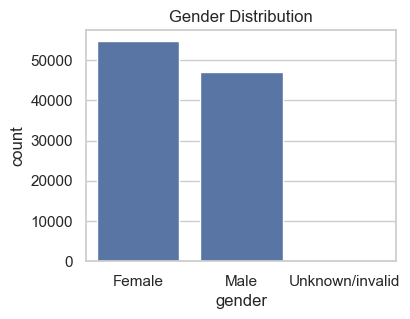

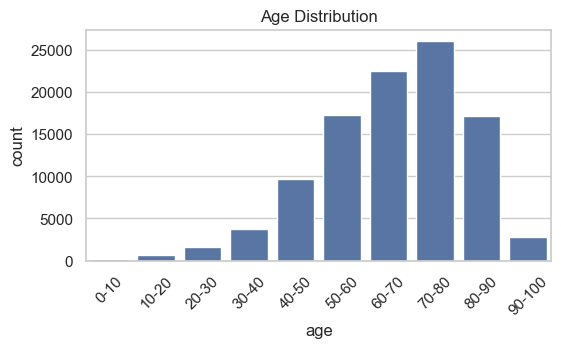

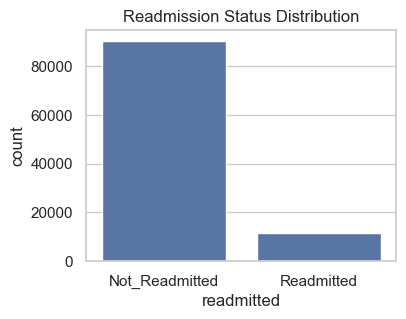

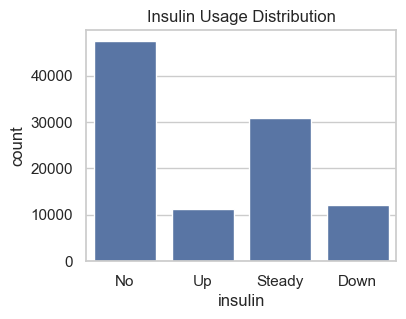

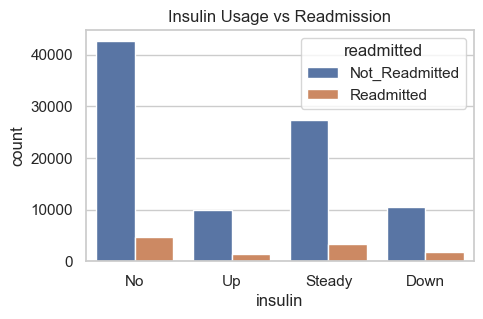

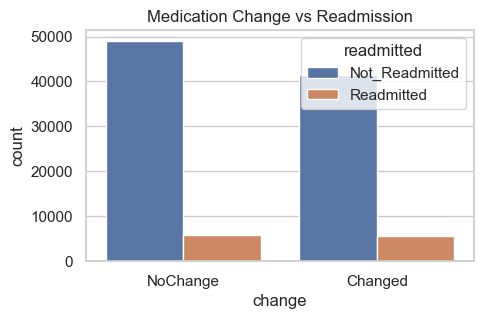

In [7]:

# ============================================
# 3. EDA
# ============================================

plt.figure(figsize=(4,3))
sns.countplot(data=df, x='gender')
plt.title("Gender Distribution")
plt.show()

plt.figure(figsize=(6,3))
sns.countplot(data=df, x='age', order=sorted(df['age'].unique()))
plt.title("Age Distribution")
plt.xticks(rotation=45)
plt.show()

plt.figure(figsize=(4,3))
sns.countplot(data=df, x='readmitted')
plt.title("Readmission Status Distribution")
plt.show()

plt.figure(figsize=(4,3))
sns.countplot(data=df, x='insulin')
plt.title("Insulin Usage Distribution")
plt.show()

plt.figure(figsize=(5,3))
sns.countplot(data=df, x='insulin', hue='readmitted')
plt.title("Insulin Usage vs Readmission")
plt.show()

plt.figure(figsize=(5,3))
sns.countplot(data=df, x='change', hue='readmitted')
plt.title("Medication Change vs Readmission")
plt.show()



## 4. Build Transactions for Association Rule Mining



In [8]:
def build_transactions_with_unique_dx(df):
    transactions = []
    for _, row in df.iterrows():
        # gather mapped diag categories
        dxs = [
            row.get('diag_1_cat39', None),
            row.get('diag_2_cat39', None),
            row.get('diag_3_cat39', None)
        ]
        # filter out invalid or unknown entries
        dxs = [d for d in dxs if pd.notna(d) and str(d).strip() not in ("", "Unknown", "NAN", "?")]
        # unique set of diagnosis categories
        unique_dx = sorted(set(dxs))
        dx_items = [f"Dx_{d.replace(' ', '_')}" for d in unique_dx]

        # other items
        other_items = [
            f"Gender_{row.get('gender','Unknown')}",
            f"Age_{row.get('age','Unknown')}",
            f"Insulin_{row.get('insulin','Unknown')}",
            f"Change_{row.get('change','Unknown')}",
            f"Readmission_{row.get('readmitted','Unknown')}"
        ]

        items = dx_items + other_items
        transactions.append(items)
    return transactions

transactions = build_transactions_with_unique_dx(df)

# Quick check
transactions[:5]

[['Dx_Endocrine_disorders',
  'Gender_Female',
  'Age_0-10',
  'Insulin_No',
  'Change_NoChange',
  'Readmission_Not_Readmitted'],
 ['Dx_Endocrine_disorders',
  'Dx_Fluid_and_electrolyte_disorders',
  'Gender_Female',
  'Age_10-20',
  'Insulin_Up',
  'Change_Changed',
  'Readmission_Not_Readmitted'],
 ['Dx_Endocrine_disorders',
  'Dx_Factors_Influencing_Health_Status_and_Contact_with_Health_Services_(V_Codes)',
  'Dx_Pregnancy,_childbirth,_and_puerperium',
  'Gender_Female',
  'Age_20-30',
  'Insulin_No',
  'Change_NoChange',
  'Readmission_Not_Readmitted'],
 ['Dx_Cardiovascular_disorders',
  'Dx_Endocrine_disorders',
  'Dx_Infectious_disorders',
  'Gender_Male',
  'Age_30-40',
  'Insulin_Up',
  'Change_Changed',
  'Readmission_Not_Readmitted'],
 ['Dx_Endocrine_disorders',
  'Dx_Neoplasms',
  'Gender_Male',
  'Age_40-50',
  'Insulin_Steady',
  'Change_Changed',
  'Readmission_Not_Readmitted']]


## 5. One-Hot Encode Transactions
We use `TransactionEncoder` from **mlxtend** to convert the transaction list into a boolean matrix.


In [9]:

# ============================================
# 5. TRANSACTION ENCODING (ONE-HOT)
# ============================================

te = TransactionEncoder()
print("Fitting TransactionEncoder...")
te_ary = te.fit(transactions)

print("Number of unique items:", len(te.columns_))

print("Transforming transactions...")
te_ary = te.transform(transactions)

df_encoded = pd.DataFrame(te_ary, columns=te.columns_)
print("Encoded shape:", df_encoded.shape)
df_encoded.head()


Fitting TransactionEncoder...
Number of unique items: 55
Transforming transactions...
Encoded shape: (101766, 55)


,Age_0-10,Age_10-20,Age_20-30,Age_30-40,Age_40-50,Age_50-60,Age_60-70,Age_70-80,Age_80-90,Age_90-100,...,"Dx_Varicose_veins,_haemorrhoids,_and_lymphatic_disorders",Gender_Female,Gender_Male,Gender_Unknown/invalid,Insulin_Down,Insulin_No,Insulin_Steady,Insulin_Up,Readmission_Not_Readmitted,Readmission_Readmitted
0,True,False,False,False,False,False,False,False,False,False,...,False,True,False,False,False,True,False,False,True,False
1,False,True,False,False,False,False,False,False,False,False,...,False,True,False,False,False,False,False,True,True,False
2,False,False,True,False,False,False,False,False,False,False,...,False,True,False,False,False,True,False,False,True,False
3,False,False,False,True,False,False,False,False,False,False,...,False,False,True,False,False,False,False,True,True,False
4,False,False,False,False,True,False,False,False,False,False,...,False,False,True,False,False,False,True,False,True,False



## 6. Subset into Readmitted Groups

We will mine patterns **only for readmitted patients** and later evaluate those patterns in both groups.


In [10]:

# ============================================
# 6. SUBSET TO READMITTED PATIENTS FOR FP-GROWTH
# ============================================

mask_readm = df['readmitted'] == 'Readmitted'
mask_not   = df['readmitted'] == 'Not_Readmitted'

df_encoded_readm = df_encoded[mask_readm.values].copy()
df_encoded_not   = df_encoded[mask_not.values].copy()

print("Readmitted shape     :", df_encoded_readm.shape)
print("Not readmitted shape :", df_encoded_not.shape)

# Drop readmission columns (they are constant inside each subgroup)
readm_cols = [c for c in df_encoded_readm.columns if c.startswith('Readmission_')]
df_encoded_readm.drop(columns=readm_cols, inplace=True)
df_encoded_not.drop(columns=readm_cols, inplace=True)

print("Readmitted (no readmission columns) shape:", df_encoded_readm.shape)


Readmitted shape     : (11357, 55)
Not readmitted shape : (90409, 55)
Readmitted (no readmission columns) shape: (11357, 53)



## 7. Prune Very Rare Items

To speed up FP-Growth, we remove item columns that are extremely rare in the readmitted group.


In [11]:
# ============================================
# 7. PRUNE ONLY NON-DIAGNOSIS ITEMS
# ============================================

# Identify Dx columns and other columns
dx_cols = [c for c in df_encoded_readm.columns if c.startswith("Dx_")]
other_cols = [c for c in df_encoded_readm.columns if not c.startswith("Dx_")]

# Prune only the non-diagnosis columns
min_item_support_other = 0.003  # 0.3%
support_other = df_encoded_readm[other_cols].mean()

keep_other = support_other[support_other >= min_item_support_other].index.tolist()

# Final kept items = ALL Dx + the pruned non-Dx
keep_items = sorted(set(dx_cols).union(set(keep_other)))

df_small_readm = df_encoded_readm[keep_items].copy()
df_small_not   = df_encoded_not[keep_items].copy()

print("Dx columns kept:", len(dx_cols))
print("Other columns kept:", len(keep_other))
print("Total columns after pruning:", df_small_readm.shape[1])


Dx columns kept: 34
Other columns kept: 17
Total columns after pruning: 51



## 8. Run FP-Growth on Readmitted Patients



In [12]:
# ============================================
# 8. RUN FP-GROWTH ON READMITTED PATIENTS ONLY
# ============================================

min_support_readm = 0.003   # 0.3% support

# Start timer
start_time_fp = time.time()

frequent_itemsets_readm = fpgrowth(
    df_small_readm,
    min_support=min_support_readm,
    use_colnames=True,
    max_len=3
)

# End timer
end_time_fp = time.time()

fp_runtime = end_time_fp - start_time_fp

print("FP-Growth Runtime (seconds):", fp_runtime)
print("Number of frequent itemsets in readmitted group:", len(frequent_itemsets_readm))

frequent_itemsets_readm.head(20)



FP-Growth Runtime (seconds): 138.94508242607117
Number of frequent itemsets in readmitted group: 2165


,support,itemsets
0,0.489390,(Change_Changed)
1,0.458308,(Gender_Male)
2,0.302281,(Insulin_Steady)
3,0.220305,(Age_60-70)
4,0.066215,(Dx_Neoplasms)
5,0.061020,(Dx_Hematologic_disorders)
6,0.575152,(Dx_Cardiovascular_disorders)
7,0.541692,(Gender_Female)
8,0.379502,(Dx_Endocrine_disorders)
9,0.149511,(Insulin_Down)



## 9. Evaluate Patterns in Both Groups (Support, Confidence, Lift)

For each pattern (itemset) discovered in the readmitted group, we compute:

- **support_readmitted**: proportion of readmitted patients with the pattern  
- **support_not_readmitted**: proportion of not-readmitted patients with the pattern  
- **confidence**: P(Readmitted | pattern)  
- **lift_readmitted_vs_not**: how many times more common the pattern is in readmitted than not-readmitted  


In [13]:

# ============================================
# 9. EVALUATE PATTERNS IN BOTH GROUPS
# ============================================

def support_in_group(itemset, df_group):

    cols = list(itemset)
    return df_group[cols].all(axis=1).mean()

rows = []
for _, row in frequent_itemsets_readm.iterrows():
    items = row['itemsets']
    
    supp_r  = support_in_group(items, df_small_readm)
    supp_nr = support_in_group(items, df_small_not)
    
    # Confidence: P(Readmitted | pattern)
    # = support(pattern in readmitted) / support(pattern in all patients)
    total_support = supp_r + supp_nr
    confidence = supp_r / (total_support + 1e-9)
    
    # Lift: how many times more common in readmitted vs not-readmitted
    lift = supp_r / (supp_nr + 1e-9)
    
    rows.append({
        "itemset": items,
        "support_readmitted": supp_r,
        "support_not_readmitted": supp_nr,
        "confidence_readmitted_given_pattern": confidence,
        "lift_readmitted_vs_not": lift
    })

comparison_df = pd.DataFrame(rows)

# Sort by lift (then support) to see most "risky" patterns first
comparison_df_sorted = comparison_df.sort_values(
    ["lift_readmitted_vs_not", "support_readmitted"],
    ascending=[False, False]
)

comparison_df_sorted.head(20)


,itemset,support_readmitted,support_not_readmitted,confidence_readmitted_given_pattern,lift_readmitted_vs_not
197,"(Dx_Neoplasms, Dx_Factors_Influencing_Health_S...",0.003170,0.000929,0.773330,3.411700
195,"(Dx_Neoplasms, Change_Changed, Dx_Factors_Infl...",0.004315,0.001372,0.758788,3.145735
198,"(Dx_Neoplasms, Age_60-70, Dx_Factors_Influenci...",0.003522,0.001161,0.752022,3.032623
199,"(Dx_Neoplasms, Dx_Factors_Influencing_Health_S...",0.005019,0.001692,0.747839,2.965727
1844,"(Insulin_Up, Gender_Female, Age_20-30)",0.005195,0.001869,0.735391,2.779157
1858,"(Dx_Fluid_and_electrolyte_disorders, Gender_Fe...",0.004403,0.001725,0.718428,2.551486
1851,"(Dx_Digestive_system_disorders, Gender_Female,...",0.003258,0.001305,0.713970,2.496131
127,"(Dx_Neoplasms, Dx_Factors_Influencing_Health_S...",0.008805,0.003562,0.712002,2.472248
1852,"(Dx_Digestive_system_disorders, Dx_Endocrine_d...",0.003962,0.001725,0.696633,2.296337
1849,"(Gender_Female, Age_20-30, Insulin_Down)",0.004843,0.002135,0.694056,2.268575



## 10. Select High-Risk Patterns

We can now filter patterns by:
- minimum support in readmitted group  
- minimum lift  
- minimum confidence  


In [16]:
# ============================================
# 10. FILTER PATTERNS
# ============================================

min_supp_r = 0.003   # 0.3% of readmitted → better for Dx patterns
min_lift   = 1.4     # 1.4x more common in readmitted
min_conf   = 0.18    # 18% probability of readmission given the pattern

filtered = comparison_df_sorted[
    (comparison_df_sorted["support_readmitted"] >= min_supp_r) &
    (comparison_df_sorted["lift_readmitted_vs_not"] >= min_lift) &
    (comparison_df_sorted["confidence_readmitted_given_pattern"] >= min_conf)
]

print("Number of strong patterns found:", len(filtered))

pd.set_option('display.max_colwidth', None)

# Keep only itemsets that include at least one diagnosis category
def contains_dx(itemset):
    return any(item.startswith("Dx_") for item in itemset)

filtered_dx_only = filtered[filtered["itemset"].apply(contains_dx)]

#Show top 20 Dx-containing rules
filtered_dx_only[['itemset', 
                 'support_readmitted', 
                 'confidence_readmitted_given_pattern',
                 'lift_readmitted_vs_not']].head(20)

# filtered_dx_only[['itemset', 
#                   'support_readmitted', 
#                   'confidence_readmitted_given_pattern',
#                   'lift_readmitted_vs_not']].to_csv(
#     'top_rules_filtered_dx_only.csv',
#     index=False
# )


Number of strong patterns found: 167


,itemset,support_readmitted,confidence_readmitted_given_pattern,lift_readmitted_vs_not
197,"(Dx_Neoplasms, Dx_Factors_Influencing_Health_Status_and_Contact_with_Health_Services_(V_Codes), Insulin_Steady)",0.003170,0.773330,3.411700
195,"(Dx_Neoplasms, Change_Changed, Dx_Factors_Influencing_Health_Status_and_Contact_with_Health_Services_(V_Codes))",0.004315,0.758788,3.145735
198,"(Dx_Neoplasms, Age_60-70, Dx_Factors_Influencing_Health_Status_and_Contact_with_Health_Services_(V_Codes))",0.003522,0.752022,3.032623
199,"(Dx_Neoplasms, Dx_Factors_Influencing_Health_Status_and_Contact_with_Health_Services_(V_Codes), Gender_Male)",0.005019,0.747839,2.965727
1858,"(Dx_Fluid_and_electrolyte_disorders, Gender_Female, Age_20-30)",0.004403,0.718428,2.551486
1851,"(Dx_Digestive_system_disorders, Gender_Female, Age_20-30)",0.003258,0.713970,2.496131
127,"(Dx_Neoplasms, Dx_Factors_Influencing_Health_Status_and_Contact_with_Health_Services_(V_Codes))",0.008805,0.712002,2.472248
1852,"(Dx_Digestive_system_disorders, Dx_Endocrine_disorders, Age_20-30)",0.003962,0.696633,2.296337
1860,"(Dx_Endocrine_disorders, Age_20-30, Dx_Factors_Influencing_Health_Status_and_Contact_with_Health_Services_(V_Codes))",0.003170,0.687937,2.204484
1843,"(Insulin_Up, Dx_Endocrine_disorders, Age_20-30)",0.006252,0.687426,2.199242
